In [16]:
import math
import re
import numpy as np
from tqdm import tqdm
import torch


# config loader
def load_config(filename):
    params = {}
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            key, value = re.split(r"\s*=\s*", line)
            try:
                if "." in value or "e" in value.lower():
                    params[key] = float(value)
                else:
                    params[key] = int(value)
            except ValueError:
                params[key] = value
    return params


# helper functions
def make_angles(n, dtype=torch.float32, device="cpu"):
    # generate view angles from 0 to (n-1)*pi/n
    step = math.pi / n
    return torch.arange(n, dtype=dtype, device=device) * step


def det_centers(N, dch, off_bins, dtype=torch.float32, device="cpu"):
    # detector bin center positions
    idx = torch.arange(N, dtype=dtype, device=device)
    return (idx - (N - 1) / 2.0 - off_bins) * dch


def build_pixel_profiles_vectorized(angles, DeltaPix, LEN_PIX, dtype=torch.float32, device="cpu"):
    """
    Build trapezoidal pixel footprint table
    Output shape: [views, profile_index]
    """
    V = angles.numel()
    pi = torch.pi

    # fold angles into range [0, pi/2)
    ang = angles.remainder(pi / 2)

    cos_a = torch.cos(ang).clamp_min(1e-12)
    cos_b = torch.cos((pi / 2) - ang).clamp_min(1e-12)

    maxval = torch.where(ang <= (pi / 4), DeltaPix / cos_a, DeltaPix / cos_b)

    rc = torch.sin(torch.tensor(pi / 4, dtype=dtype, device=device))
    d1 = rc * torch.cos((pi / 4) - ang)
    d2 = rc * torch.abs(torch.sin((pi / 4) - ang))

    t1 = 1.0 - d1
    t2 = 1.0 - d2
    t3 = 1.0 + d2
    t4 = 1.0 + d1

    uj = torch.arange(LEN_PIX, dtype=dtype, device=device)
    t = (2.0 * uj / float(LEN_PIX)).unsqueeze(0)

    t1e = t1.unsqueeze(1)
    t2e = t2.unsqueeze(1)
    t3e = t3.unsqueeze(1)
    t4e = t4.unsqueeze(1)
    maxval_e = maxval.unsqueeze(1)

    rising = (t > t1e) & (t <= t2e)
    plateau = (t > t2e) & (t <= t3e)
    falling = (t > t3e) & (t <= t4e)

    den_rise = (t2e - t1e).clamp_min(1e-12)
    den_fall = (t4e - t3e).clamp_min(1e-12)

    P = torch.zeros((V, LEN_PIX), dtype=dtype, device=device)

    P = torch.where(rising, maxval_e * (t - t1e) / den_rise, P)
    P = torch.where(plateau, maxval_e, P)
    P = torch.where(falling, maxval_e * (t4e - t) / den_fall, P)

    return P


def profile_index_tensorized(t_i, s0, DeltaPix, LEN_PIX):
    # convert detector coordinate to footprint index
    u_float = ((t_i - s0) + DeltaPix) * (LEN_PIX - 1.0) / (2.0 * DeltaPix)
    u = torch.floor(u_float + 0.5).to(torch.int64)
    return torch.clamp(u, 0, LEN_PIX - 1)


def profile_interp_tensorized(t_i, s0, DeltaPix, LEN_PIX, P_view):
    """
    Linear interpolation lookup in footprint table
    """
    u_float = ((t_i - s0) + DeltaPix) * (LEN_PIX - 1.0) / (2.0 * DeltaPix)

    u0 = torch.floor(u_float).to(torch.int64)
    u1 = u0 + 1

    u0 = torch.clamp(u0, 0, LEN_PIX - 1)
    u1 = torch.clamp(u1, 0, LEN_PIX - 1)

    alpha = (u_float - u0.to(u_float.dtype)).clamp(0.0, 1.0)

    k = torch.arange(P_view.shape[0], device=P_view.device)

    w0 = P_view[k, u0]
    w1 = P_view[k, u1]

    return (1.0 - alpha) * w0 + alpha * w1


# main routine
def main():

    # device and datatype
    device = "cpu"
    dtype = torch.float32

    # load configuration parameters
    config = load_config("config.txt")

    Nx = int(config["Nx"])
    Ny = int(config["Ny"])
    Nz = int(config["Nz"])

    Deltaxy = float(config["Deltaxy"])
    DeltaZ = float(config["DeltaZ"])

    ROIRadius = float(config["ROIRadius"])
    FirstSliceNumber = int(config["FirstSliceNumber"])

    NViews = int(config["NViews"])
    NChan = int(config["NChan"])

    DeltaCh = float(config["DeltaCh"])
    CenterOff = float(config["CenterOff"])

    DeltaSlice = float(config["DeltaSlice"])

    LEN_PIX = int(config["LEN_PIX"])
    BIN = int(config["BIN"])

    OUT_A = "/content/A_parallel_params.npz"

    print("Loaded parameters:")
    for k, v in config.items():
        print(f"  {k} = {v}")

    if NChan % BIN != 0:
        raise ValueError(f"NChan ({NChan}) must be divisible by BIN ({BIN}).")

    nchan = NChan // BIN
    dch = DeltaCh * BIN
    coff = CenterOff / BIN

    # compute view angles and detector centers
    angles = make_angles(NViews, dtype=dtype, device=device)
    tcent = det_centers(nchan, dch, coff, dtype=dtype, device=device)

    # build pixel footprint table
    P = build_pixel_profiles_vectorized(angles, Deltaxy, LEN_PIX, dtype=dtype, device=device)

    # system matrix dimensions
    V = NViews
    C = nchan

    Nrows = V * C
    Ncols = Nx * Ny

    DeltaPix = Deltaxy

    # storage for sparse matrix entries
    r_all = []
    c_all = []
    v_all = []

    cos_th = torch.cos(angles)
    sin_th = torch.sin(angles)

    t0 = float(tcent[0].item())

    # build system matrix column by column
    for j in tqdm(range(Ncols), desc="Building A", unit="pixel"):

        jx = j % Nx
        jy = j // Nx

        x = (jx - (Nx - 1) / 2.0) * Deltaxy
        y = (jy - (Ny - 1) / 2.0) * Deltaxy

        s0 = y * cos_th - x * sin_th

        tmin = s0 - DeltaPix
        tmax = s0 + DeltaPix

        i_min = torch.ceil((tmin - t0) / dch - 0.5).to(torch.int64)
        i_max = torch.floor((tmax - t0) / dch + 0.5).to(torch.int64)

        i_min = torch.clamp(i_min, 0, C - 1)
        i_max = torch.clamp(i_max, 0, C - 1)

        lens = (i_max - i_min + 1).clamp_min(0)

        total = int(lens.sum().item())

        if total == 0:
            continue

        Lmax = int(lens.max().item())

        base = torch.arange(Lmax, device=device)

        valid = base.unsqueeze(0) < lens.unsqueeze(1)

        i_mat = i_min.unsqueeze(1) + base.unsqueeze(0)

        i_idx = i_mat[valid]

        p_idx = torch.arange(V, device=device).repeat_interleave(lens)

        # detector integration using three samples
        t_base = tcent[i_idx]

        s0_p = s0[p_idx]

        P_sel = P[p_idx]

        offsets = torch.tensor([-0.25, 0.0, 0.25], dtype=dtype, device=device) * dch

        w_sum = torch.zeros_like(t_base)

        for off in offsets:

            t_i = t_base + off

            w_sum += profile_interp_tensorized(t_i, s0_p, DeltaPix, LEN_PIX, P_sel)

        w = w_sum / offsets.numel()

        nz_mask = w > 0

        if nz_mask.any():
            p_idx = p_idx[nz_mask]
            i_idx = i_idx[nz_mask]
            w = w[nz_mask]
        else:
            continue

        rows = (p_idx.to(torch.int64) * C + i_idx.to(torch.int64)).tolist()

        cols = [j] * len(rows)

        vals = w.to(torch.float32).tolist()

        r_all.extend(rows)
        c_all.extend(cols)
        v_all.extend(vals)

    # convert lists to tensors
    r_all = torch.tensor(r_all, dtype=torch.int64)
    c_all = torch.tensor(c_all, dtype=torch.int64)
    v_all = torch.tensor(v_all, dtype=dtype)

    # save sparse system matrix
    a_matrix = {
        "row_idx_all": r_all.cpu().numpy(),
        "col_idx_all": c_all.cpu().numpy(),
        "val_all": v_all.cpu().numpy(),
        "Nrows": np.int64(Nrows),
        "Ncols": np.int64(Ncols),
        "Nx": np.int64(Nx),
        "Ny": np.int64(Ny),
        "Nz": np.int64(Nz),
        "Deltaxy": np.float64(Deltaxy),
        "LEN_PIX": np.int64(LEN_PIX),
        "NViews": np.int64(NViews),
        "NChannels": np.int64(C),
        "DeltaChannel": np.float64(dch),
        "CenterOffset": np.float64(coff),
        "DeltaSlice": np.float64(DeltaSlice),
        "BIN": np.int64(BIN),
    }

    np.savez_compressed("/content/A_parallel_params.npz", **a_matrix)

    print(f"saved /content/A_parallel_params.npz | rows={Nrows} cols={Ncols} nnz={r_all.numel()}")


if __name__ == "__main__":
    # run without gradient tracking
    with torch.inference_mode():
        main()

Loaded parameters:
  Nx = 128
  Ny = 128
  Nz = 1
  Deltaxy = 4
  DeltaZ = 4
  ROIRadius = 250
  FirstSliceNumber = 1
  NViews = 288
  NChan = 512
  DeltaCh = 0.9765625
  CenterOff = -6
  DeltaSlice = 0.9765625
  LEN_PIX = 511
  BIN = 1


Building A: 100%|██████████| 16384/16384 [00:52<00:00, 310.51pixel/s]


saved /content/A_parallel_params.npz | rows=147456 cols=16384 nnz=25116166


device: cuda
grid: 256 256  views: 225  det: 1024
sino: (225, 1024) min/max: -0.11988259851932526 0.7530611753463745
||y||2: 158.57444763183594 ||Ax0||2: 0.16886122524738312
   1  L=1.678e+07  F=1.678e+07  R=1.738e-06  lr=0.05
  25  L=1.106e+07  F=1.106e+07  R=1.328e-04  lr=0.05
  50  L=7.170e+06  F=7.170e+06  R=1.350e-02  lr=0.05
  75  L=4.935e+06  F=4.935e+06  R=2.260e-01  lr=0.05
 100  L=3.394e+06  F=3.394e+06  R=1.097e+00  lr=0.05
 125  L=2.205e+06  F=2.205e+06  R=2.601e+00  lr=0.05
 150  L=1.361e+06  F=1.361e+06  R=4.513e+00  lr=0.05
 175  L=8.049e+05  F=8.049e+05  R=6.953e+00  lr=0.05
 200  L=4.893e+05  F=4.893e+05  R=9.885e+00  lr=0.05
 225  L=3.602e+05  F=3.602e+05  R=1.541e+01  lr=0.05
 250  L=3.156e+05  F=3.156e+05  R=3.066e+01  lr=0.05
 275  L=2.876e+05  F=2.876e+05  R=4.900e+01  lr=0.05
 300  L=2.682e+05  F=2.681e+05  R=6.631e+01  lr=0.05
 325  L=2.538e+05  F=2.538e+05  R=8.286e+01  lr=0.05
 350  L=2.429e+05  F=2.428e+05  R=9.845e+01  lr=0.05
 375  L=2.344e+05  F=2.343e+05 

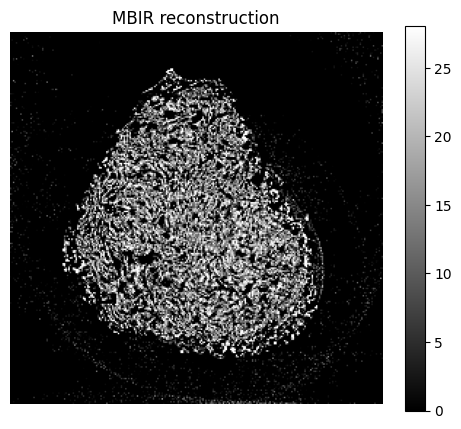

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# paths
A_PATH = "A_parallel_params.npz"
SINO_PATH = "/content/xradia_slice0700.2Dsinodata"
W_PATH = "/content/xradia_slice0700.2Dweightdata"


# device
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    torch.cuda.set_device(0)
print("device:", device)


# hyperparameters
ITERS = 1500
LR = 0.05
PATIENCE = 80
MIN_DELTA = 1e-4
CLIP_NORM = 1.0

# QGGMRF parameters
SIGMA_X = 0.1
P = 1.2
Q = 2.0
T = 1.0


# load system matrix
A = np.load(A_PATH)

row_idx = torch.tensor(A["row_idx_all"], dtype=torch.long, device=device)
col_idx = torch.tensor(A["col_idx_all"], dtype=torch.long, device=device)
aval = torch.tensor(A["val_all"], dtype=torch.float32, device=device)

Nx = int(A["Nx"])
Ny = int(A["Ny"])
V = int(A["NViews"])
C = int(A["NChannels"])

print(f"grid: {Nx} {Ny}  views: {V}  det: {C}")


# load sinogram
with open(SINO_PATH, "rb") as f:
    flat = np.frombuffer(f.read(), dtype=np.float32)

y = torch.tensor(flat.reshape(V, C), dtype=torch.float32, device=device)
print("sino:", tuple(y.shape), "min/max:", y.min().item(), y.max().item())


# load weights
with open(W_PATH, "rb") as f:
    wflat = np.frombuffer(f.read(), dtype=np.float32)

w = torch.tensor(wflat.reshape(V, C), dtype=torch.float32, device=device)
w_sqrt = torch.sqrt(torch.clamp(w, min=0.0))


# forward model: Ax
def forward_model(x):
    xflat = x.view(-1)
    yflat = torch.zeros(V * C, dtype=torch.float32, device=device)
    yflat.index_add_(0, row_idx, aval * xflat[col_idx])
    return yflat.view(V, C)


# adjoint operation for init
def adjoint_operation(yin):
    yflat = yin.reshape(-1)
    xflat = torch.zeros(Nx * Ny, dtype=torch.float32, device=device)
    xflat.index_add_(0, col_idx, aval * yflat[row_idx])
    return xflat.view(Nx, Ny)


# QGGMRF prior energy
def qggmrf_energy(x, sigma_x, p, q, T):
    eps = 1e-8

    dx = x[:, 1:] - x[:, :-1]
    dy = x[1:, :] - x[:-1, :]
    d1 = x[1:, 1:] - x[:-1, :-1]
    d2 = x[1:, :-1] - x[:-1, 1:]

    def rho(d):
        a = torch.abs(d) + eps
        r = (a / (T * sigma_x + eps)) ** (q - p)
        return ((a / (sigma_x + eps)) ** p) * (r / (1.0 + r))

    energy = (
        rho(dx).sum()
        + rho(dy).sum()
        + 0.707 * rho(d1).sum()
        + 0.707 * rho(d2).sum()
    )

    return energy / x.numel()


# loss function
def loss_fn(x):
    Ax = forward_model(x)
    r = (Ax - y) * w_sqrt
    data_term = torch.sum(r * r)
    prior = qggmrf_energy(x, SIGMA_X, P, Q, T)
    total = data_term + prior
    return total, data_term, prior


# initialization
with torch.no_grad():
    x0 = adjoint_operation(y)
    x0 = torch.clamp(x0, min=0.0)
    x0 = x0 / (torch.max(x0) + 1e-12)
    x0 = 0.01 * x0

x = x0.clone().detach().requires_grad_(True)

# optimizer
opt = torch.optim.Adam([x], lr=LR)

sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=20,
    min_lr=1e-4
)


# sanity check
with torch.no_grad():
    Ax0 = forward_model(x)

print("||y||2:", y.norm().item(), "||Ax0||2:", Ax0.norm().item())


# training
best_loss = float("inf")
best_x = x.detach().clone()
stall = 0

for it in range(1, ITERS + 1):
    opt.zero_grad()

    total, data_term, prior = loss_fn(x)
    total.backward()

    torch.nn.utils.clip_grad_norm_([x], CLIP_NORM)
    opt.step()

    with torch.no_grad():
        x.clamp_(min=0.0)

    loss_val = total.item()

    if not np.isfinite(loss_val):
        print("nan encountered")
        break

    sched.step(loss_val)

    if loss_val < best_loss - MIN_DELTA:
        best_loss = loss_val
        best_x = x.detach().clone()
        stall = 0
    else:
        stall += 1

    if it % 25 == 0 or it == 1:
        print(
            f"{it:4d}  "
            f"L={total.item():.3e}  "
            f"F={data_term.item():.3e}  "
            f"R={prior.item():.3e}  "
            f"lr={opt.param_groups[0]['lr']:.3g}"
        )

    if stall >= PATIENCE:
        print("early stop")
        break

x = best_x




# plot

xnp = x.detach().cpu().numpy()
p2, p98 = np.percentile(xnp, [2, 98])
if p2 == p98:
    p2, p98 = xnp.min(), xnp.max()

plt.figure(figsize=(6, 5))
plt.imshow(xnp, cmap="gray", vmin=p2, vmax=p98)
plt.axis("off")
plt.colorbar()
plt.title("MBIR reconstruction")
plt.show()

device: cuda
grid: 128 128  views: 288  det: 512
sino: (288, 512) min/max: -0.0 3.020509958267212
||y||2: 540.2686157226562 ||Ax0||2: 1122.8740234375
   1  L=2.729e+05  F=2.729e+05  R=4.055e-05  lr=0.05
  25  L=5.603e+04  F=5.603e+04  R=2.033e-03  lr=0.05
  50  L=1.510e+04  F=1.510e+04  R=1.717e-03  lr=0.025
  75  L=6.364e+02  F=6.364e+02  R=1.642e-03  lr=0.0125
 100  L=7.793e+02  F=7.793e+02  R=1.634e-03  lr=0.00625
 125  L=7.602e+02  F=7.602e+02  R=1.666e-03  lr=0.00625
 150  L=1.252e+02  F=1.252e+02  R=1.656e-03  lr=0.00313
 175  L=1.623e+02  F=1.623e+02  R=1.652e-03  lr=0.00313
 200  L=1.189e+02  F=1.189e+02  R=1.658e-03  lr=0.00156
 225  L=1.156e+02  F=1.156e+02  R=1.653e-03  lr=0.00156
 250  L=1.074e+02  F=1.074e+02  R=1.657e-03  lr=0.000781
 275  L=1.072e+02  F=1.072e+02  R=1.657e-03  lr=0.000391
 300  L=1.072e+02  F=1.072e+02  R=1.656e-03  lr=0.000391
 325  L=1.072e+02  F=1.072e+02  R=1.656e-03  lr=0.000195
 350  L=1.072e+02  F=1.072e+02  R=1.656e-03  lr=0.0001
 375  L=1.072e+0

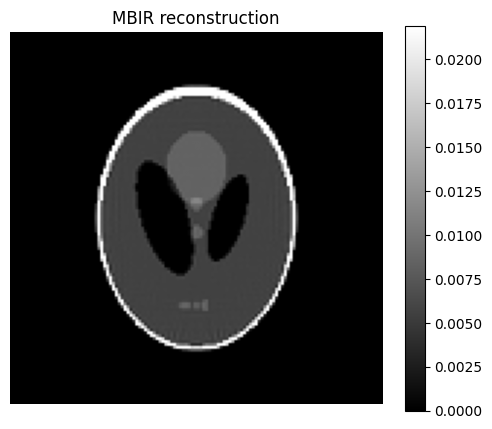

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# paths
A_PATH = "A_parallel_params.npz"
SINO_PATH = "/content/shepp_slice0001.2Dsinodata"
W_PATH = "/content/shepp_slice0001.2Dweightdata"

# device
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    torch.cuda.set_device(0)
print("device:", device)


# hyperparameters
ITERS = 1500
LR = 0.05
PATIENCE = 80
MIN_DELTA = 1e-4
CLIP_NORM = 1.0

# QGGMRF parameters
SIGMA_X = 0.635
P = 1.2
Q = 2.0
T = 0.000478


# load system matrix
A = np.load(A_PATH)

row_idx = torch.tensor(A["row_idx_all"], dtype=torch.long, device=device)
col_idx = torch.tensor(A["col_idx_all"], dtype=torch.long, device=device)
aval = torch.tensor(A["val_all"], dtype=torch.float32, device=device)

Nx = int(A["Nx"])
Ny = int(A["Ny"])
V = int(A["NViews"])
C = int(A["NChannels"])

print(f"grid: {Nx} {Ny}  views: {V}  det: {C}")


# load sinogram
with open(SINO_PATH, "rb") as f:
    flat = np.frombuffer(f.read(), dtype=np.float32)

y = torch.tensor(flat.reshape(V, C), dtype=torch.float32, device=device)
print("sino:", tuple(y.shape), "min/max:", y.min().item(), y.max().item())


# load weights
with open(W_PATH, "rb") as f:
    wflat = np.frombuffer(f.read(), dtype=np.float32)

w = torch.tensor(wflat.reshape(V, C), dtype=torch.float32, device=device)
w_sqrt = torch.sqrt(torch.clamp(w, min=0.0))


# forward model: Ax
def forward_model(x):
    xflat = x.view(-1)
    yflat = torch.zeros(V * C, dtype=torch.float32, device=device)
    yflat.index_add_(0, row_idx, aval * xflat[col_idx])
    return yflat.view(V, C)


# adjoint operation for init
def adjoint_operation(yin):
    yflat = yin.reshape(-1)
    xflat = torch.zeros(Nx * Ny, dtype=torch.float32, device=device)
    xflat.index_add_(0, col_idx, aval * yflat[row_idx])
    return xflat.view(Nx, Ny)


# QGGMRF prior energy
def qggmrf_energy(x, sigma_x, p, q, T):
    eps = 1e-8

    dx = x[:, 1:] - x[:, :-1]
    dy = x[1:, :] - x[:-1, :]
    d1 = x[1:, 1:] - x[:-1, :-1]
    d2 = x[1:, :-1] - x[:-1, 1:]

    def rho(d):
        a = torch.abs(d) + eps
        r = (a / (T * sigma_x + eps)) ** (q - p)
        return ((a / (sigma_x + eps)) ** p) * (r / (1.0 + r))

    energy = (
        rho(dx).sum()
        + rho(dy).sum()
        + 0.707 * rho(d1).sum()
        + 0.707 * rho(d2).sum()
    )

    return energy / x.numel()

# loss function
def loss_fn(x):
    Ax = forward_model(x)
    r = (Ax - y) * w_sqrt
    data_term = torch.sum(r * r)
    prior = qggmrf_energy(x, SIGMA_X, P, Q, T)
    total = data_term + prior
    return total, data_term, prior

# initialization
with torch.no_grad():
    x0 = adjoint_operation(y)
    x0 = torch.clamp(x0, min=0.0)
    x0 = x0 / (torch.max(x0) + 1e-12)
    x0 = 0.01 * x0

x = x0.clone().detach().requires_grad_(True)


# optimizer
opt = torch.optim.Adam([x], lr=LR)

sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=20,
    min_lr=1e-4
)

# sanity check
with torch.no_grad():
    Ax0 = forward_model(x)

print("||y||2:", y.norm().item(), "||Ax0||2:", Ax0.norm().item())


# training
best_loss = float("inf")
best_x = x.detach().clone()
stall = 0

for it in range(1, ITERS + 1):
    opt.zero_grad()

    total, data_term, prior = loss_fn(x)
    total.backward()

    torch.nn.utils.clip_grad_norm_([x], CLIP_NORM)
    opt.step()

    with torch.no_grad():
        x.clamp_(min=0.0)

    loss_val = total.item()

    if not np.isfinite(loss_val):
        print("nan encountered")
        break

    sched.step(loss_val)

    if loss_val < best_loss - MIN_DELTA:
        best_loss = loss_val
        best_x = x.detach().clone()
        stall = 0
    else:
        stall += 1

    if it % 25 == 0 or it == 1:
        print(
            f"{it:4d}  "
            f"L={total.item():.3e}  "
            f"F={data_term.item():.3e}  "
            f"R={prior.item():.3e}  "
            f"lr={opt.param_groups[0]['lr']:.3g}"
        )

    if stall >= PATIENCE:
        print("early stop")
        break

x = best_x


# plot

xnp = x.detach().cpu().numpy()
p2, p98 = np.percentile(xnp, [2, 98])
if p2 == p98:
    p2, p98 = xnp.min(), xnp.max()

plt.figure(figsize=(6, 5))
plt.imshow(xnp, cmap="gray", vmin=p2, vmax=p98)
plt.axis("off")
plt.colorbar()
plt.title("MBIR reconstruction")
plt.show()